# TP Final — Detección de sub-declaración de ingresos (ARCA)


Dataset: *Adult / Census Income* (UCI), reinterpretado para este escenario ficticio.

Este notebook retoma el trabajo desde la **Parte 3 de la consigna (Pipeline de trabajo)**. Las partes 1 y 2 (justificación del dataset, del problema y de las variables) ya fueron presentadas y validadas por la cátedra; acá se avanza sobre EDA, limpieza, separación train/test, baseline y primeros modelos.


## 0. Entorno y dependencias


**Cómo usarlo (una sola vez):**
1. Correr las dos celdas de esta sección.
2. Ir al selector de kernel del notebook (arriba a la derecha, o `Kernel → Change Kernel`) y elegir **`Python (tp-arca)`**.
3. `Restart & Run All` para que el resto del notebook corra ya dentro del entorno aislado.

Si se saltea el paso 2, el `.venv` se crea igual y las dependencias quedan instaladas ahí, pero el resto de las celdas van a seguir corriendo con el kernel que ya estaba activo (típicamente porque ya se corrió una vez este notebook y ese es justamente el entorno que armamos).

In [1]:
import sys
import subprocess
import pathlib

VENV_DIR = pathlib.Path(".venv")

if not VENV_DIR.exists():
    subprocess.run([sys.executable, "-m", "venv", str(VENV_DIR)], check=True)
    print(f"Entorno virtual creado en: {VENV_DIR.resolve()}")
else:
    print(f"Ya existe un entorno virtual en: {VENV_DIR.resolve()}")

VENV_PYTHON = VENV_DIR / ("Scripts/python.exe" if sys.platform == "win32" else "bin/python")
print("Intérprete del venv:", VENV_PYTHON.resolve())


Ya existe un entorno virtual en: /home/feli/Documents/ITBA/ML/TP_FInal/.venv
Intérprete del venv: /usr/bin/python3.12


In [2]:
REQUIREMENTS = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scipy",
    "scikit-learn",
    "ipykernel",
]

with open("requirements.txt", "w") as f:
    f.write("\n".join(REQUIREMENTS) + "\n")

subprocess.run([str(VENV_PYTHON), "-m", "pip", "install", "--upgrade", "pip", "-q"], check=True)
subprocess.run([str(VENV_PYTHON), "-m", "pip", "install", "-r", "requirements.txt", "-q"], check=True)

try:
    subprocess.run(
        [str(VENV_PYTHON), "-m", "ipykernel", "install", "--user",
         "--name", "tp-arca", "--display-name", "Python (tp-arca)"],
        check=True,
    )
    print("Dependencias instaladas y kernel 'Python (tp-arca)' registrado y disponible para seleccionar.")
except subprocess.CalledProcessError as e:
    print("Dependencias instaladas. No se pudo registrar el kernel automáticamente:", e)
    print("Se puede registrar a mano corriendo:")
    print(f"  {VENV_PYTHON} -m ipykernel install --user --name tp-arca --display-name 'Python (tp-arca)'")


Installed kernelspec tp-arca in /home/feli/.local/share/jupyter/kernels/tp-arca
Dependencias instaladas y kernel 'Python (tp-arca)' registrado y disponible para seleccionar.


In [3]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)  # esperable con el baseline (siempre predice una sola clase)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 3.1 Carga de datos

El archivo original no trae encabezado, así que asignamos los nombres de columnas según el diccionario del dataset UCI Adult.

In [4]:
COLS = ["age","workclass","fnlwgt","education","education_num","marital_status",
        "occupation","relationship","race","sex","capital_gain","capital_loss",
        "hours_per_week","native_country","income"]

df = pd.read_csv("adult.csv", header=None, names=COLS, skipinitialspace=True)
print(df.shape)
df.head()


(32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3.2 Análisis exploratorio (EDA)

### 3.2.1 Calidad de datos: tipos, nulos, duplicados

El dataset no tiene `NaN` explícitos, pero usa el string `"?"` como marca de dato faltante en variables categóricas.

In [5]:
print(df.dtypes)
print()
for c in df.select_dtypes(include="object").columns:
    n = (df[c] == "?").sum()
    if n > 0:
        print(f"{c}: {n} faltantes ({n/len(df)*100:.2f}%)")

print("\nDuplicados exactos:", df.duplicated().sum())


age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object

workclass: 1836 faltantes (5.64%)
occupation: 1843 faltantes (5.66%)
native_country: 583 faltantes (1.79%)

Duplicados exactos: 24


/tmp/ipykernel_164908/2028227014.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include="object").columns:


**Decisión:** `workclass` y `occupation` faltan casi siempre juntas (cuando falta una, falta la otra en 1836 de 1843 casos), lo cual sugiere que la falta de dato no es aleatoria: probablemente corresponde a personas sin relación de dependencia formal. Por eso, en vez de imputar por la moda o eliminar esas filas (perderíamos ~7% de los datos y probablemente un patrón real), las vamos a imputar con una categoría explícita `"Sin_dato"`, preservando la señal de que el dato falta.

`native_country` también tiene faltantes (1.79%), pero la vamos a eliminar por completo más abajo — ver justificación en 3.3.

### 3.2.2 Balance del target

El target real de negocio es *"¿el declarante gana más del umbral?"*, que en este dataset corresponde a `income`.

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


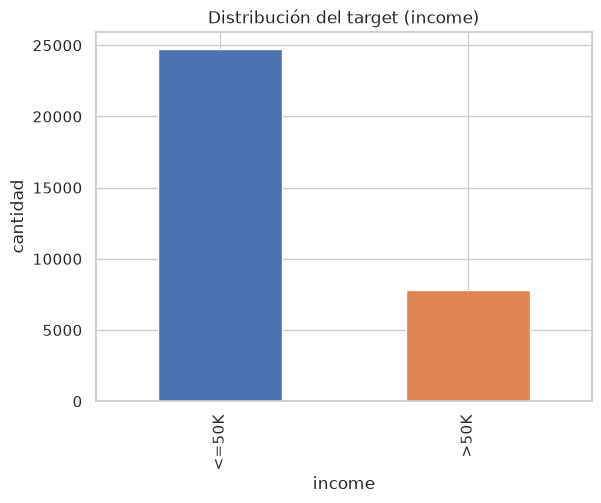

In [6]:
df["target"] = (df["income"] == ">50K").astype(int)
print(df["income"].value_counts(normalize=True))

ax = df["income"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_title("Distribución del target (income)")
ax.set_ylabel("cantidad")
plt.show()


Confirma lo que ya habíamos anticipado en la Entrega 1: desbalance ~76% / 24%. Esto va a condicionar tanto el baseline como las métricas que usemos para evaluar (accuracy sola no alcanza).

### 3.2.3 Variables numéricas: distribución y relación con el target

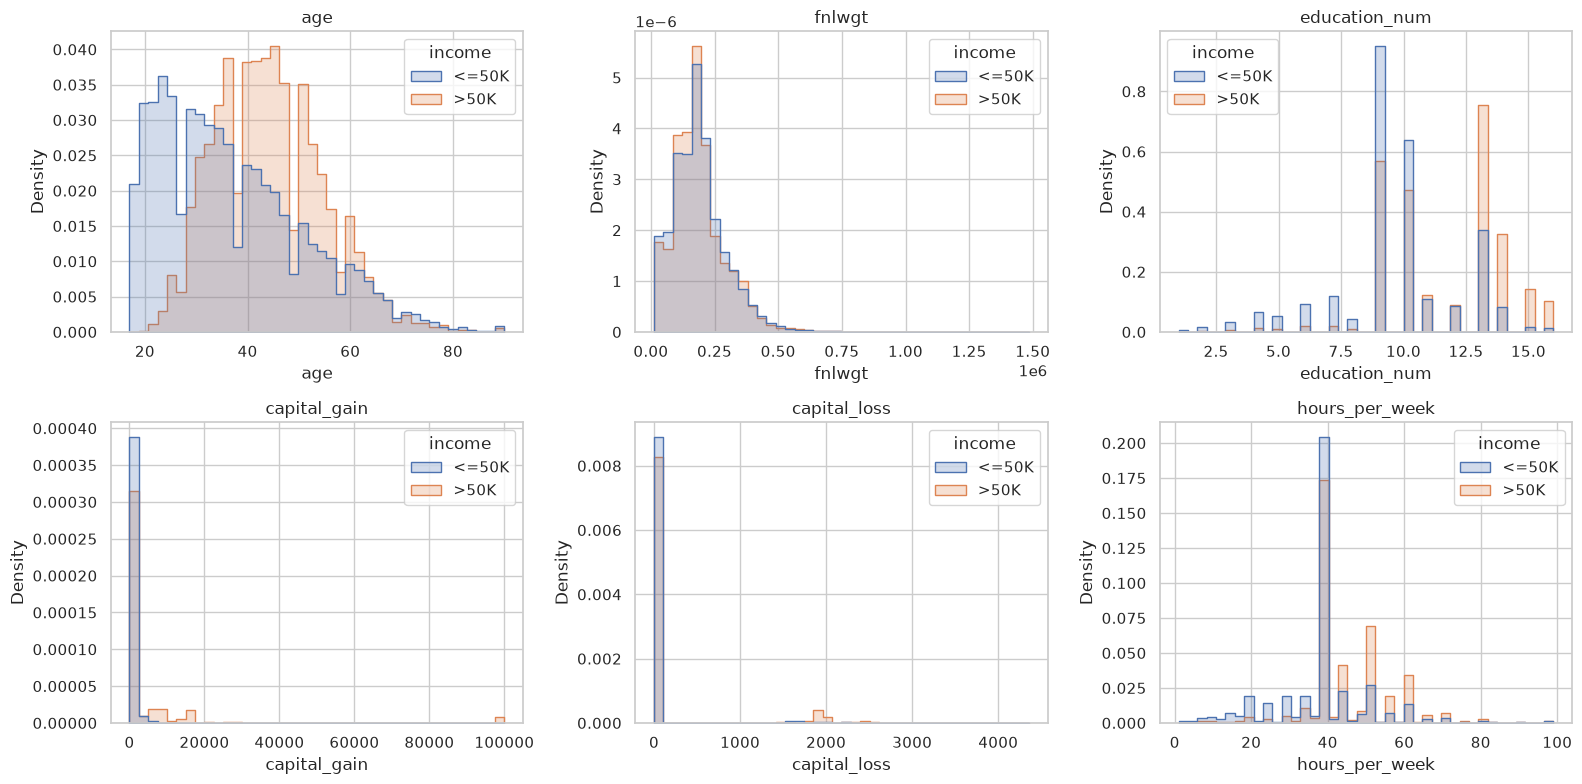

In [7]:
num_cols = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(data=df, x=c, hue="income", bins=40, ax=ax, element="step", stat="density", common_norm=False)
    ax.set_title(c)
plt.tight_layout()
plt.show()


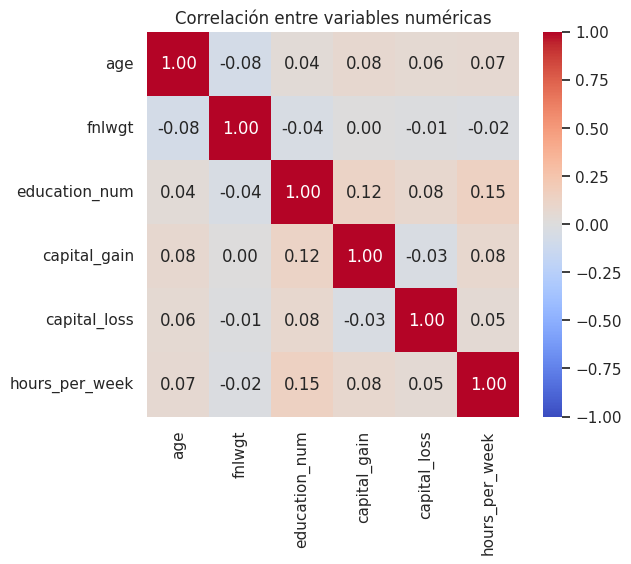

Correlación punto-biserial con el target:
  age              r=+0.234  p=0.0e+00
  fnlwgt           r=-0.009  p=8.8e-02
  education_num    r=+0.335  p=0.0e+00
  capital_gain     r=+0.223  p=0.0e+00
  capital_loss     r=+0.151  p=2.7e-164
  hours_per_week   r=+0.230  p=0.0e+00


In [8]:
corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables numéricas")
plt.show()

print("Correlación punto-biserial con el target:")
for c in num_cols:
    r, p = pointbiserialr(df["target"], df[c])
    print(f"  {c:16s} r={r:+.3f}  p={p:.1e}")


**Lectura:**
- No hay multicolinealidad fuerte entre las numéricas (todas las correlaciones cruzadas son bajas).
- `education_num` (r≈0.34), `age`, `capital_gain`, `hours_per_week` (r≈0.23) y `capital_loss` (r≈0.15) están asociadas al target.
- `fnlwgt` prácticamente no correlaciona con el target (r≈-0.01, no significativa). Esto confirma lo que ya habíamos señalado en la Entrega 1: es un peso muestral del censo, no una característica del individuo, y **no tiene sentido en este problema** (en producción no existiría un "peso de encuesta" por declarante). Se descarta.
- `hours_per_week` sí es predictiva (r≈0.23), pero **la descartamos igual**: no es un dato que vaya a estar disponible en una declaración impositiva real. Preferimos un pipeline con datos que existan en producción antes que una métrica más alta con una variable que no vamos a tener (esto lo retomamos en la sección 4, riesgos y uso real).

### 3.2.4 Variables categóricas: relación con el target

Usamos **V de Cramér** como medida de asociación (más apropiada que la correlación para variables categóricas).

relationship      0.453585
marital_status    0.447404
education         0.368838
occupation        0.351892
sex               0.215904
workclass         0.179208
race              0.100812
native_country    0.098705
dtype: float64


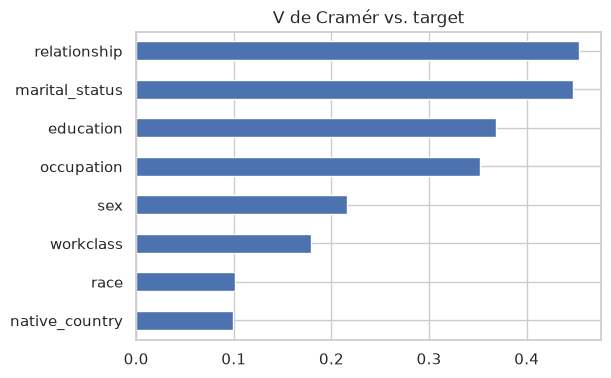

In [8]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols = ["workclass", "education", "marital_status", "occupation",
            "relationship", "race", "sex", "native_country"]

assoc = pd.Series({c: cramers_v(df[c], df["income"]) for c in cat_cols}).sort_values(ascending=False)
print(assoc)

assoc.plot(kind="barh", figsize=(6,4))
plt.title("V de Cramér vs. target")
plt.gca().invert_yaxis()
plt.show()


**Lectura:**
- `relationship`, `marital_status`, `occupation` y `education` son las más asociadas al target.
- `race` (V≈0.10) y `native_country` (V≈0.10) tienen asociación débil con el target **además** de los problemas ya señalados en la Entrega 1 (variables poco pertinentes o mal representadas para el contexto argentino). Esto refuerza la decisión de descartarlas — no perdemos poder predictivo relevante.
- `education` está perfectamente redundada por `education_num` (chequeo abajo), así que nos quedamos solo con la versión numérica ordinal.

In [9]:
print(df.groupby("education")["education_num"].unique())


education
10th             [6]
11th             [7]
12th             [8]
1st-4th          [2]
5th-6th          [3]
7th-8th          [4]
9th              [5]
Assoc-acdm      [12]
Assoc-voc       [11]
Bachelors       [13]
Doctorate       [16]
HS-grad          [9]
Masters         [14]
Preschool        [1]
Prof-school     [15]
Some-college    [10]
Name: education_num, dtype: object


### 3.2.5 Nota sobre `native_country`

Se había dejado pendiente en la Entrega 1. Lo cuantificamos acá:

In [10]:
print(f"% United-States: {(df['native_country']=='United-States').mean()*100:.1f}%")
print(f"Cantidad de categorías distintas: {df['native_country'].nunique()}")
df["native_country"].value_counts(normalize=True).head(8) * 100


% United-States: 89.6%
Cantidad de categorías distintas: 42


native_country
United-States    89.585701
Mexico            1.974755
?                 1.790486
Philippines       0.608089
Germany           0.420749
Canada            0.371610
Puerto-Rico       0.350112
El-Salvador       0.325543
Name: proportion, dtype: float64

**Decisión: se descarta.** Tres motivos combinados:
1. Asociación débil con el target (V≈0.10, similar a `race`, que ya descartamos por motivos parecidos).
2. ~90% de los casos son `United-States` y el resto se reparte en 40 categorías con muy pocos casos cada una — casi no aporta variabilidad utilizable, y encima el desbalance geográfico responde al contexto de EE.UU., no al argentino (mismo problema que señalamos para `race`).
3. Reinterpretarla como binaria (`"local"` vs. `"extranjero"`) es técnicamente posible, pero dado el punto 1 el aporte esperado es marginal, así que no se justifica la complejidad extra ni el 1.8% de imputación que exigiría. Si el análisis de errores más adelante muestra un patrón sistemático relacionado con origen, se puede reconsiderar.

### 3.2.6 Nota sobre `sex` y `race`: variables sensibles

`sex` sí tiene asociación relevante con el target (V≈0.22) y una disparidad grande en la tasa de la clase positiva:

In [11]:
print(df.groupby("sex")["target"].mean())


sex
Female    0.109461
Male      0.305737
Name: target, dtype: float64


Por ahora la mantenemos como feature (tiene poder predictivo real en el dataset y no la habíamos marcado como problemática en la Entrega 1), pero queda anotada como **riesgo a monitorear**: un modelo de riesgo fiscal que aprenda a asociar género con sospecha de sub-declaración es un problema ético y legal serio si eso se traduce en más auditorías a un grupo por su género en lugar de por su conducta. Lo retomamos en la sección 4 (riesgos).

## 3.3 Limpieza y selección de variables

Resumen de decisiones:

| Variable | Decisión | Motivo |
|---|---|---|
| `fnlwgt` | eliminar | peso muestral del censo, sin sentido a nivel individuo, sin correlación con el target |
| `race` | eliminar | no se usa institucionalmente en Argentina para este tipo de análisis; asociación débil |
| `native_country` | eliminar | asociación débil, 90% concentrado en una categoría, contexto no aplica a Argentina |
| `hours_per_week` | eliminar | no disponible en una declaración impositiva real (no existiría en producción) |
| `education` | eliminar | redundante con `education_num` |
| `workclass`, `occupation` | mantener, imputar `"?"` → `"Sin_dato"` | faltante no aleatorio, aporta info |
| resto | mantener | ver EDA |


In [12]:
DROP_COLS = ["fnlwgt", "race", "native_country", "hours_per_week", "education", "income"]

df_clean = df.drop(columns=DROP_COLS).copy()
df_clean = df_clean.drop_duplicates()

for c in ["workclass", "occupation"]:
    df_clean[c] = df_clean[c].replace("?", "Sin_dato")

print(df_clean.shape)
df_clean.head()


(22427, 10)


,age,workclass,education_num,marital_status,occupation,relationship,sex,capital_gain,capital_loss,target
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,0


## 3.4 Separación train / test

Usamos **partición estratificada** por el target: como el desbalance es 76/24, un split aleatorio simple podría dejar proporciones distintas en train y test por azar, sobre todo si en algún fold quedan pocos positivos. Con `stratify` forzamos que ambos conjuntos mantengan la misma proporción de clases que el dataset completo.

In [13]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["target"])
y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.mean().round(3))
print("Test: ", X_test.shape, y_test.mean().round(3))


Train: (17941, 9) 0.261
Test:  (4486, 9) 0.261


## 3.5 Preprocesamiento

Armamos un `ColumnTransformer` para no tener que normalizar/encodear "a mano" y para que el mismo pipeline se pueda aplicar en train y test sin fugas de información (el `fit` del scaler y del encoder se hace **solo** con train).

- Numéricas → `StandardScaler` (media 0, desvío 1). Necesario para la regresión logística; no afecta a Random Forest pero no molesta tenerlo en el mismo pipeline.
- Categóricas → `OneHotEncoder` (con `handle_unknown="ignore"` por si en test aparece alguna categoría rara no vista en train).

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_features = ["age", "education_num", "capital_gain", "capital_loss"]
categorical_features = ["workclass", "marital_status", "occupation", "relationship", "sex"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])


### 3.5.1 Vista del dataset ya procesado

Antes de seguir, vale la pena ver cómo queda la matriz que realmente entra al modelo: numéricas ya escaladas y categóricas ya en one-hot. Ajustamos el `preprocessor` solo con train (para no filtrar información de test) y mostramos un `head()`.

In [15]:
preprocessor_fitted = preprocessor.fit(X_train)
feature_names = preprocessor_fitted.get_feature_names_out()

X_train_transformed = preprocessor_fitted.transform(X_train)
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

X_train_proc = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)
print(f"Forma final: {X_train_proc.shape[0]} filas x {X_train_proc.shape[1]} columnas "
      f"({len(numeric_features)} numéricas escaladas + {X_train_proc.shape[1]-len(numeric_features)} dummies de one-hot)")
X_train_proc.head()


Forma final: 17941 filas x 43 columnas (4 numéricas escaladas + 39 dummies de one-hot)


,num__age,num__education_num,num__capital_gain,num__capital_loss,cat__workclass_Federal-gov,cat__workclass_Local-gov,cat__workclass_Never-worked,cat__workclass_Private,cat__workclass_Self-emp-inc,cat__workclass_Self-emp-not-inc,cat__workclass_Sin_dato,cat__workclass_State-gov,cat__workclass_Without-pay,cat__marital_status_Divorced,cat__marital_status_Married-AF-spouse,cat__marital_status_Married-civ-spouse,cat__marital_status_Married-spouse-absent,cat__marital_status_Never-married,cat__marital_status_Separated,cat__marital_status_Widowed,cat__occupation_Adm-clerical,cat__occupation_Armed-Forces,cat__occupation_Craft-repair,cat__occupation_Exec-managerial,cat__occupation_Farming-fishing,cat__occupation_Handlers-cleaners,cat__occupation_Machine-op-inspct,cat__occupation_Other-service,cat__occupation_Priv-house-serv,cat__occupation_Prof-specialty,cat__occupation_Protective-serv,cat__occupation_Sales,cat__occupation_Sin_dato,cat__occupation_Tech-support,cat__occupation_Transport-moving,cat__relationship_Husband,cat__relationship_Not-in-family,cat__relationship_Other-relative,cat__relationship_Own-child,cat__relationship_Unmarried,cat__relationship_Wife,cat__sex_Female,cat__sex_Male
13656,-0.786339,-0.400272,-0.172626,-0.261625,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
31906,0.527302,0.673162,-0.172626,-0.261625,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2571,-1.443159,-0.042460,-0.172626,-0.261625,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4060,-0.056538,1.030974,-0.172626,-0.261625,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
20595,0.965183,-0.400272,0.339869,-0.261625,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 3.6 Baseline y primeros modelos

**Principio metodológico para todo lo que sigue:** el test se toca una única vez, al final, para reportar resultados — no para tomar decisiones durante el desarrollo (comparar modelos, elegir hiperparámetros, validar una métrica nueva). Para eso está la validación cruzada: nos deja comparar y elegir usando solamente `X_train`/`y_train`, sin gastar el test antes de tiempo.

Entonces: el baseline y los primeros modelos (regresión logística y Random Forest, con hiperparámetros por defecto) se evalúan acá con `cross_validate` sobre train. El baseline predice siempre la clase mayoritaria (`<=50K`); para accuracy esto equivale, a grandes rasgos, a la proporción de la clase más numerosa (~76%, ya lo vimos en el EDA). Igual que con los modelos, lo confirmamos con la misma metodología (CV) para que la comparación sea pareja.

In [16]:
from sklearn.model_selection import cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

lr_pipe = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
# n_estimators moderado acá (100) solo para que esta primera pasada de sanity-check sea rápida;
# el número de árboles se vuelve a discutir en la búsqueda de hiperparámetros (3.9).
rf_pipe = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1))])
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

cv_results = {}
for name, est in [("Baseline", dummy), ("Regresión Logística", lr_pipe), ("Random Forest", rf_pipe)]:
    cv = cross_validate(est, X_train, y_train, cv=5, scoring=scoring, n_jobs=1)
    cv_results[name] = {m: cv[f"test_{m}"].mean() for m in scoring}

cv_comparison = pd.DataFrame(cv_results).T.round(3)
cv_comparison


,accuracy,precision,recall,f1,roc_auc
Baseline,0.739,0.000,0.000,0.000,0.500
Regresión Logística,0.832,0.722,0.579,0.642,0.889
Random Forest,0.801,0.632,0.571,0.600,0.849


**Lectura (todo esto sobre train, vía CV — todavía no vimos test):**
- El baseline, como se esperaba, tiene accuracy "gratis" (~76%) pero recall y F1 en cero: nunca marca a nadie como sospechoso. Cualquier modelo tiene que superarlo en recall/F1/ROC-AUC, no solo en accuracy.
- La regresión logística supera al Random Forest "de fábrica" en casi todas las métricas. Con hiperparámetros por defecto (profundidad libre, pocos árboles), el RF probablemente está sobreajustando un poco sobre el espacio disperso de las variables one-hot. Lo retomamos en la búsqueda de hiperparámetros (3.9) — buen ejemplo de por qué la consigna pide no usar modelos complejos "porque sí": acá, sin tunear, el modelo más simple gana.

## 3.7 Predicciones con probabilidad y ranking de riesgo

El equipo de auditoría necesita una lista ordenada por riesgo, no un sí/no binario — por eso usamos `predict_proba` en vez de quedarnos solo con `predict`. Para ilustrar cómo se ve ese ranking sin gastar el test, usamos `cross_val_predict`: cada fila del train queda predicha por un modelo que **no la vio** durante el entrenamiento de ese fold (predicción "out-of-fold"), así que el ranking es honesto aunque sea sobre datos de train.

In [18]:
from sklearn.model_selection import cross_val_predict

proba_oof_lr = cross_val_predict(lr_pipe, X_train, y_train, cv=5, method="predict_proba", n_jobs=1)[:, 1]
proba_oof_rf = cross_val_predict(rf_pipe, X_train, y_train, cv=5, method="predict_proba", n_jobs=1)[:, 1]

ranking_oof_lr = pd.DataFrame(
    {"y_real": y_train.values, "proba_subdeclaracion": proba_oof_lr}, index=X_train.index
).sort_values("proba_subdeclaracion", ascending=False)

print("Top 15 según riesgo estimado (regresión logística, out-of-fold sobre train):")
ranking_oof_lr.head(1000)


Top 15 según riesgo estimado (regresión logística, out-of-fold sobre train):


,y_real,proba_subdeclaracion
26442,1,1.000000
25611,1,1.000000
12677,1,1.000000
22361,1,1.000000
2319,1,1.000000
...,...,...
13547,1,0.864085
24223,1,0.863656
30363,1,0.863614
22639,0,0.863541


Con esta tabla el equipo de auditoría podría, por ejemplo, mirar primero los 100 o 1000 casos con `proba_subdeclaracion` más alta. Esa idea es la base de las métricas de negocio de la próxima sección.

## 3.8 Métricas de negocio: ¿qué tan bien se usarían los recursos de auditoría?

Accuracy, precision, recall, F1 y ROC-AUC son necesarias pero no cuentan toda la historia: no reflejan que en producción el output que se usa es el **ranking de probabilidades**, no una clasificación binaria. Definimos dos métricas pensadas específicamente para este caso de uso, y las validamos acá con las probabilidades out-of-fold de la sección anterior (train, no test).

**1. Precisión ponderada por probabilidad (`weighted_precision`)**

Si el equipo de auditoría dedica más atención a los casos con `proba` más alta —en proporción a la probabilidad, no con un corte binario—, entonces lo que importa es qué fracción de ese "esfuerzo ponderado" cae sobre sub-declarantes reales:

$$\text{weighted\_precision} = \frac{\sum_i p_i \cdot y_i}{\sum_i p_i}$$

**2. Precisión sobre el top-N (`precision_at_n`)**

Más simple y más fácil de explicar en la Parte 5: de los N declarantes con mayor probabilidad estimada (los primeros que el equipo revisaría), ¿qué porcentaje son efectivamente sub-declarantes? La calculamos para N=100 y N=1000.

In [19]:
def weighted_precision(y_true, y_proba):
    """Fracción de la 'masa de probabilidad' repartida por el modelo que efectivamente
    cae sobre sub-declarantes reales. Pensada para un escenario donde el esfuerzo de
    auditoría se asigna en proporción a la probabilidad estimada, no con un corte binario."""
    y_true = np.asarray(y_true, dtype=float)
    y_proba = np.asarray(y_proba, dtype=float)
    denom = y_proba.sum()
    if denom == 0:
        return float("nan")  # el modelo no asignó probabilidad a la clase positiva en ningún caso
    return float((y_proba * y_true).sum() / denom)


def precision_at_n(y_true, y_proba, n):
    """De los N casos con mayor probabilidad estimada, qué fracción son positivos reales.
    Simula: 'el equipo de auditoría revisa los N casos más riesgosos, ¿cuántos son ciertos?'"""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    order = np.argsort(-y_proba)[:n]
    return float(y_true[order].mean())


def business_metrics(y_true, y_proba, ns=(100, 1000)):
    out = {"weighted_precision": weighted_precision(y_true, y_proba)}
    for n in ns:
        out[f"precision_at_{n}"] = precision_at_n(y_true, y_proba, n)
    return out


print("Validación con probabilidades out-of-fold sobre train (todavía sin tocar test):")
for name, proba in [("Regresión Logística", proba_oof_lr), ("Random Forest", proba_oof_rf)]:
    bm = business_metrics(y_train.values, proba)
    print(name, {k: round(v, 3) for k, v in bm.items()})


Validación con probabilidades out-of-fold sobre train (todavía sin tocar test):
Regresión Logística {'weighted_precision': 0.567, 'precision_at_100': 1.0, 'precision_at_1000': 0.96}
Random Forest {'weighted_precision': 0.566, 'precision_at_100': 0.98, 'precision_at_1000': 0.925}


Ya sobre train (out-of-fold) se ve el mismo patrón que con las métricas clásicas: la regresión logística está algo mejor calibrada que el Random Forest sin tunear. El top-100 de ambos modelos tiene precisión altísima igual — cuando el modelo está muy seguro, casi siempre acierta; el problema está más "en el medio" del ranking, que es justo lo que la `weighted_precision` captura al mirar todos los casos. Los números definitivos (sobre test) quedan para la sección 3.10, después de tunear.

## 3.9 Búsqueda de hiperparámetros

Probamos combinaciones de hiperparámetros con `RandomizedSearchCV` (3 folds), todo sobre `X_train`/`y_train` — el test sigue sin tocarse. Incluimos `class_weight="balanced"` como opción dado el desbalance de clases.

Usamos **scoring múltiple**: ROC-AUC como criterio principal para elegir el mejor modelo (`refit`), porque es una métrica de ranking robusta y no depende de un recorte arbitrario como el N del top-N. Además reportamos, para cada combinación, las métricas de negocio (`weighted_precision`, `precision_at_100`) a modo diagnóstico — así vemos si optimizar por ROC-AUC también mueve en la dirección correcta a las métricas que realmente le importan al caso de uso, sin optimizar directamente sobre un N que podría ser ruidoso con pocos folds.

Nota técnica: para Random Forest usamos `n_jobs=1` en el clasificador y el paralelismo en la búsqueda (`RandomizedSearchCV(n_jobs=-1)`) — paralelizar en los dos niveles a la vez satura los cores en vez de acelerar.

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

scoring_dict = {
    "roc_auc": "roc_auc",
    "weighted_precision": make_scorer(weighted_precision, response_method="predict_proba"),
    "precision_at_100": make_scorer(precision_at_n, response_method="predict_proba", n=100),
}

lr_search_pipe = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
lr_param_dist = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"],
}
lr_search = RandomizedSearchCV(
    lr_search_pipe, lr_param_dist, n_iter=8, scoring=scoring_dict, refit="roc_auc",
    cv=3, random_state=RANDOM_STATE, n_jobs=-1,
)
lr_search.fit(X_train, y_train)

best_idx = lr_search.best_index_
cvres = lr_search.cv_results_
print("Mejores hiperparámetros (Regresión Logística):", lr_search.best_params_)
print("CV — ROC-AUC:", round(cvres["mean_test_roc_auc"][best_idx], 3),
      "| weighted_precision:", round(cvres["mean_test_weighted_precision"][best_idx], 3),
      "| precision_at_100:", round(cvres["mean_test_precision_at_100"][best_idx], 3))


Mejores hiperparámetros (Regresión Logística): {'clf__class_weight': None, 'clf__C': 10}
CV — ROC-AUC: 0.889 | weighted_precision: 0.568 | precision_at_100: 0.983


In [21]:
rf_search_pipe = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))])
rf_param_dist = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [8, 16],
    "clf__min_samples_leaf": [1, 5, 20],
    "clf__class_weight": [None, "balanced"],
}
rf_search = RandomizedSearchCV(
    rf_search_pipe, rf_param_dist, n_iter=6, scoring=scoring_dict, refit="roc_auc",
    cv=3, random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train, y_train)

best_idx = rf_search.best_index_
cvres = rf_search.cv_results_
print("Mejores hiperparámetros (Random Forest):", rf_search.best_params_)
print("CV — ROC-AUC:", round(cvres["mean_test_roc_auc"][best_idx], 3),
      "| weighted_precision:", round(cvres["mean_test_weighted_precision"][best_idx], 3),
      "| precision_at_100:", round(cvres["mean_test_precision_at_100"][best_idx], 3))


Mejores hiperparámetros (Random Forest): {'clf__n_estimators': 200, 'clf__min_samples_leaf': 5, 'clf__max_depth': 16, 'clf__class_weight': None}
CV — ROC-AUC: 0.905 | weighted_precision: 0.568 | precision_at_100: 1.0


**Lectura (todavía sobre CV/train):** el tuneo le hace bien especialmente a Random Forest — con `max_depth` y `min_samples_leaf` moderados deja de sobreajustar y pasa a competir de igual a igual con la regresión logística, o incluso superarla, según la métrica. Con esto ya elegimos y fijamos los hiperparámetros de ambos modelos usando únicamente train. Recién en la próxima sección los llevamos a test.